In [50]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

In [51]:
def plot_dist_pie(df, col, title=None, label_map=None):
    counts = df[col].value_counts(dropna=False)
    
    # Apply label mapping if provided
    if label_map:
        labels = [label_map.get(x, x) for x in counts.index]
    else:
        labels = [str(x) for x in counts.index]
    
    plt.figure(figsize=(4, 4))
    plt.pie(
        counts,
        labels=labels,
        # autopct=lambda p: f'{p:.1f}%\n({int(round(p/100.*sum(counts)))})',
        autopct='%1.1f%%',
        startangle=140
    )
    plt.title(title or f"{col} distribution")
    plt.tight_layout()
    plt.show()


In [52]:
SAMPLE_DIR = Path("samples/ymyl_29000/res_20250723_n100")

# Queries
queries_df = pd.read_csv(SAMPLE_DIR.parent / "queries_ymyl_29000.csv")

# AI overviews
responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")
responses_df['references'] = responses_df['references'].apply(json.loads)
responses_df['organic_results'] = responses_df['organic_results'].apply(json.loads)
responses_df = responses_df.merge(queries_df, on="query_id")

# Document pool
classified_urls_df = pd.read_csv(SAMPLE_DIR / "__classified_urls.csv")
unclassified_urls_df = pd.read_csv(SAMPLE_DIR / "__unclassified_urls.csv")

In [53]:
ai_count = (classified_urls_df['ai_class'] == 'AI').sum()
human_count = (classified_urls_df['ai_class'] == 'Human').sum()

In [54]:
aio_query_ids = set(responses_df['query_id'])
aio_queries_df = queries_df[queries_df['query_id'].isin(aio_query_ids)]

In [55]:
print('Total queries'.ljust(15) + ':', len(queries_df))
print('Total AIOs'.ljust(15) + ':', len(responses_df))
print('Total docs'.ljust(15) + ':', len(classified_urls_df) + len(unclassified_urls_df))

print('Total class.'.ljust(15) + ':', len(classified_urls_df), f'(AI: {ai_count}, Human: {human_count})')
print('Total unclass.'.ljust(15) + ':', len(unclassified_urls_df))

Total queries  : 29000
Total AIOs     : 2597
Total docs     : 214724
Total class.   : 167856 (AI: 16973, Human: 150883)
Total unclass. : 46868


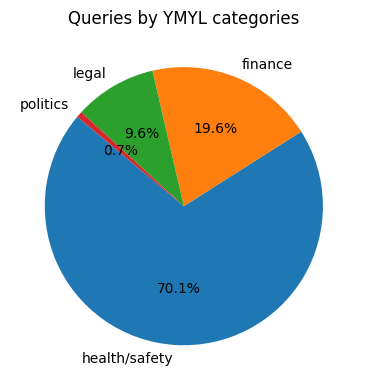

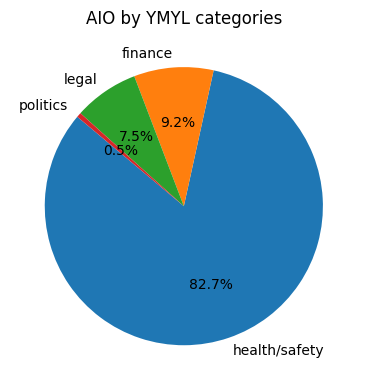

In [56]:
plot_dist_pie(queries_df, 'ymyl_category', 'Queries by YMYL categories')
plot_dist_pie(aio_queries_df, 'ymyl_category', 'AIO by YMYL categories')

health/safety queries: 20335, AIOs: 2147, AIO rate: 10.56%
finance queries: 5690, AIOs: 240, AIO rate: 4.22%
legal queries: 2772, AIOs: 196, AIO rate: 7.07%
politics queries: 203, AIOs: 14, AIO rate: 6.90%


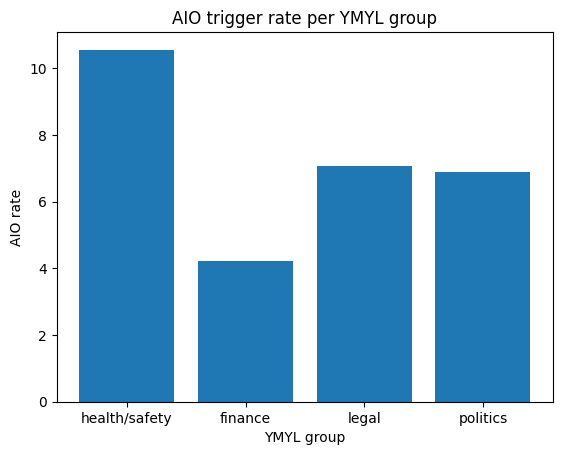

In [57]:
cats = []
rates = []

for cat in queries_df['ymyl_category'].unique():
    query_count = len(queries_df[queries_df['ymyl_category'] == cat])
    aio_count = len(aio_queries_df[aio_queries_df['ymyl_category'] == cat])
    aio_rate = aio_count / query_count * 100
    print(cat, f'queries: {query_count}, AIOs: {aio_count}, AIO rate: {aio_rate:.2f}%')
    cats.append(cat)
    rates.append(aio_rate)

plt.bar(cats, rates)
plt.xlabel("YMYL group")
plt.ylabel("AIO rate")
plt.title("AIO trigger rate per YMYL group")
plt.show()

# Blog post 1 graphics

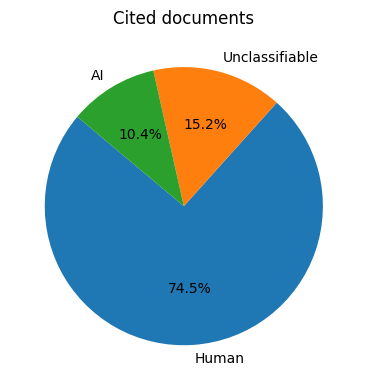

In [58]:
citations_df = (
    responses_df
    .explode('references')
    # .drop_duplicates(subset=['references'])
    .rename(columns={'references': 'url'})
    .assign(organic=lambda df: df.apply(
        lambda row: row['url'] in row['organic_results'],
        axis=1
    ))
    [['url', 'organic']]
    .reset_index(drop=True)
    .merge(classified_urls_df[['url', 'ai_class']], on='url', how='left')
    .assign(**{'class': lambda df: df['ai_class'].fillna('Unclassifiable')})
    .drop(columns=['ai_class'])
)

plot_dist_pie(citations_df, 'class', 'Cited documents')

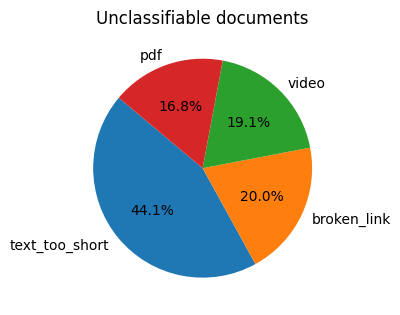

In [59]:
unclassified_citations_df = unclassified_urls_df[
    unclassified_urls_df['url'].isin(
        citations_df.loc[citations_df['class'] == 'Unclassifiable', 'url']
    )
].reset_index(drop=True)

plot_dist_pie(unclassified_citations_df, 'category', 'Unclassifiable documents')

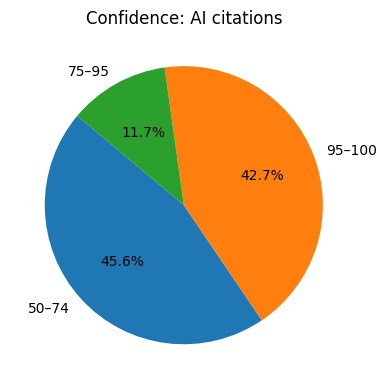

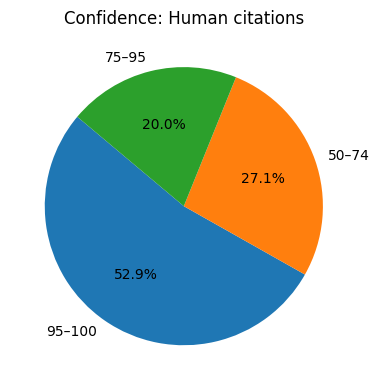

In [60]:
# AI/Human confidence buckets

cited_classified_df = classified_urls_df[
    classified_urls_df['url'].isin(citations_df['url'])
].reset_index(drop=True)

def bucket(conf):
    if conf >= 95:
        return "95–100"
    elif conf >= 75:
        return "75–95"
    elif conf >= 50:
        return "50–74"
    else:
        return "<50"

cited_classified_df["conf_bucket"] = cited_classified_df["confidence"].apply(bucket)

cited_ai_df = cited_classified_df[cited_classified_df["ai_class"] == "AI"]
cited_human_df = cited_classified_df[cited_classified_df["ai_class"] == "Human"]

plot_dist_pie(cited_ai_df, 'conf_bucket', 'Confidence: AI citations')
plot_dist_pie(cited_human_df, 'conf_bucket', 'Confidence: Human citations')

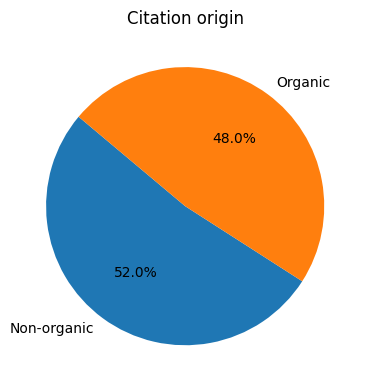

In [61]:
# Organic vs non-organic

plot_dist_pie(citations_df, 'organic', 'Citation origin', { True: 'Organic', False: 'Non-organic' })

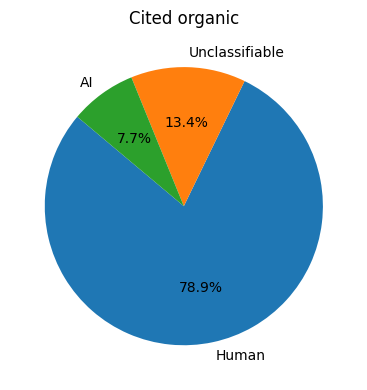

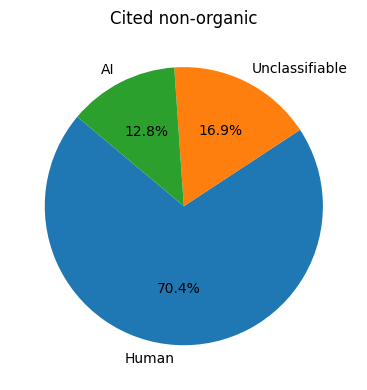

In [62]:
organic_citations_df = citations_df[citations_df['organic']]
non_organic_citations_df = citations_df[~citations_df['organic']]

plot_dist_pie(organic_citations_df, 'class', 'Cited organic')
plot_dist_pie(non_organic_citations_df, 'class', 'Cited non-organic')

# Blog post 2 graphics

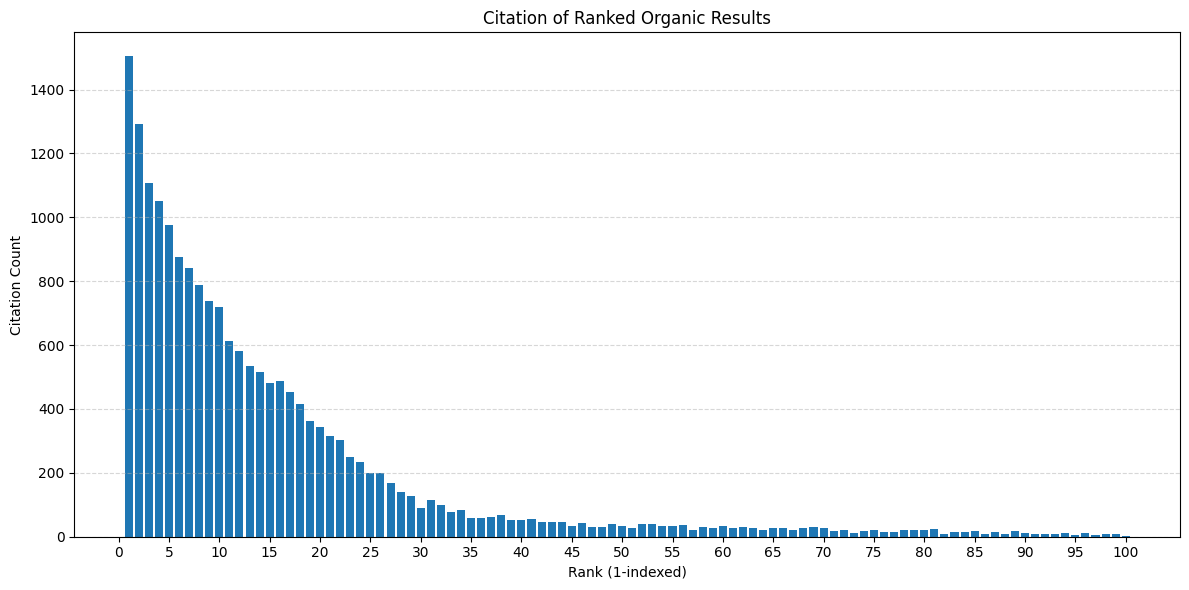

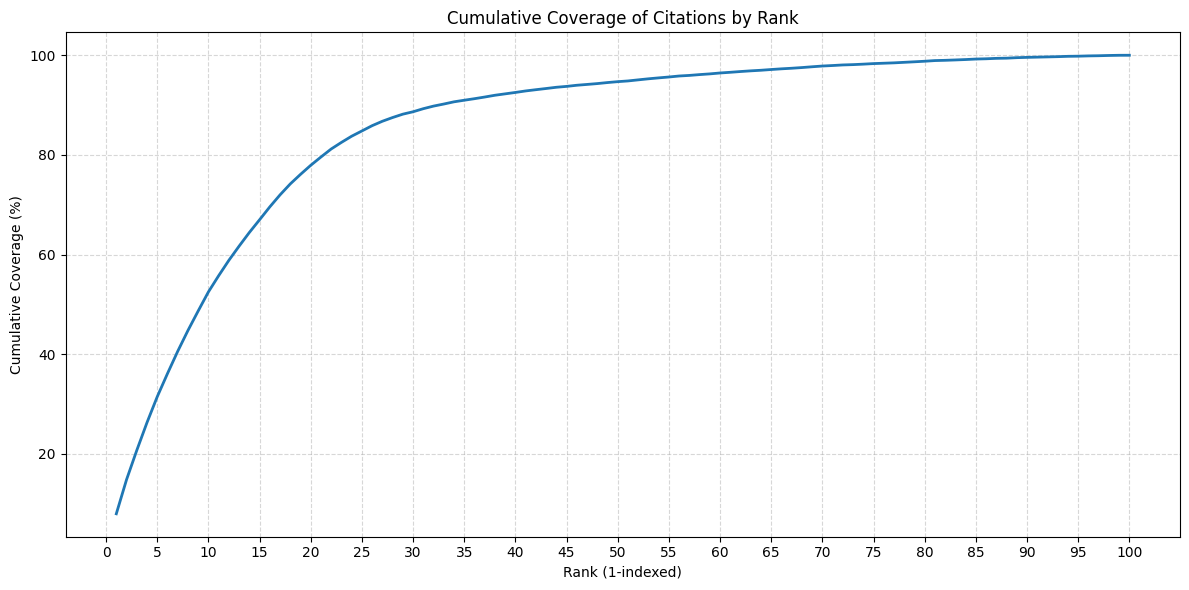

Share of citations covered by top-k ranks:
  Top-1 :   8.0%
  Top-3 :  20.7%
  Top-5 :  31.5%
  Top-10:  52.5%
  Top-20:  77.9%
  Top-30:  88.7%
  Top-40:  92.5%
  Top-50:  94.7%


In [63]:
def _count_cited_positions(responses_df, url_set, max_rank=100):
    """Return (positions, counts) where counts[i-1] is how often rank i was cited."""
    counter = Counter()
    for _, row in responses_df.iterrows():
        cited = set(row["references"])
        organic = row["organic_results"][:max_rank]
        for i, url in enumerate(organic, start=1):
            if url in cited and (url_set is None or url in url_set):
                counter[i] += 1
    positions = list(range(1, max_rank + 1))
    counts = [counter.get(i, 0) for i in positions]
    return positions, counts

def plot_cited_positions(responses_df, url_set=None, label=None, max_rank=100):
    """Bar chart: how many citations come from each rank."""
    positions, counts = _count_cited_positions(responses_df, url_set, max_rank=max_rank)

    plt.figure(figsize=(12, 6))
    plt.bar(positions, counts)
    title = "Citation of Ranked Organic Results"
    if label:
        title += f" ({label})"
    plt.title(title)
    plt.xlabel("Rank (1-indexed)")
    plt.ylabel("Citation Count")
    plt.xticks(range(0, max_rank + 1, 5))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_cited_positions_cumulative(responses_df, url_set=None, label=None, max_rank=100, as_percent=True):
    """Cumulative coverage: by rank k, what share (or count) of all citations is captured?"""
    positions, counts = _count_cited_positions(responses_df, url_set, max_rank=max_rank)
    counts = np.array(counts, dtype=np.int64)
    cum = counts.cumsum()

    plt.figure(figsize=(12, 6))
    if as_percent:
        total = cum[-1] if cum[-1] > 0 else 1
        y = 100.0 * cum / total
        plt.ylabel("Cumulative Coverage (%)")
    else:
        y = cum
        plt.ylabel("Cumulative Coverage (count)")

    plt.plot(positions, y, linewidth=2)
    title = "Cumulative Coverage of Citations by Rank"
    if label:
        title += f" ({label})"
    plt.title(title)
    plt.xlabel("Rank (1-indexed)")
    plt.xticks(range(0, max_rank + 1, 5))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def print_topk_percentages(responses_df, url_set=None, ks=[1, 3, 5, 10, 20, 30, 40, 50], max_rank=100):
    positions, counts = _count_cited_positions(responses_df, url_set, max_rank=max_rank)
    counts = np.array(counts, dtype=np.int64)
    cum = counts.cumsum()
    total = cum[-1] if cum[-1] > 0 else 1

    print("Share of citations covered by top-k ranks:")
    for k in ks:
        pct = 100.0 * cum[k-1] / total
        print(f"  Top-{k:<2}: {pct:5.1f}%")


# pass allowed urls, filter in _count_cited_positions (then pass AI/Human only)
plot_cited_positions(responses_df)
plot_cited_positions_cumulative(responses_df)
print_topk_percentages(responses_df)

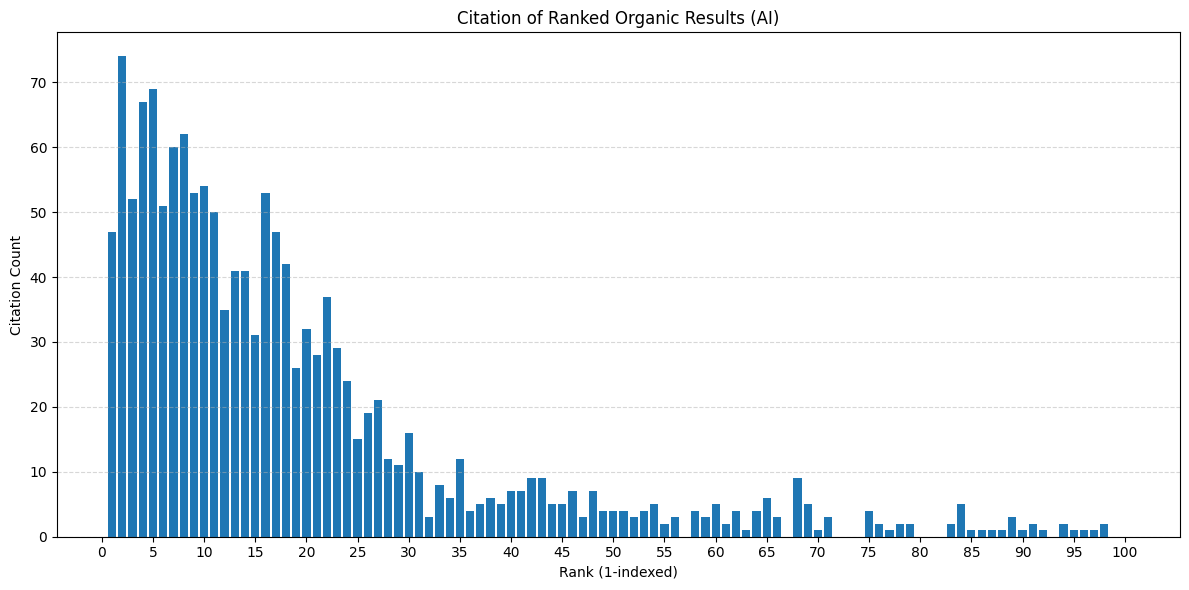

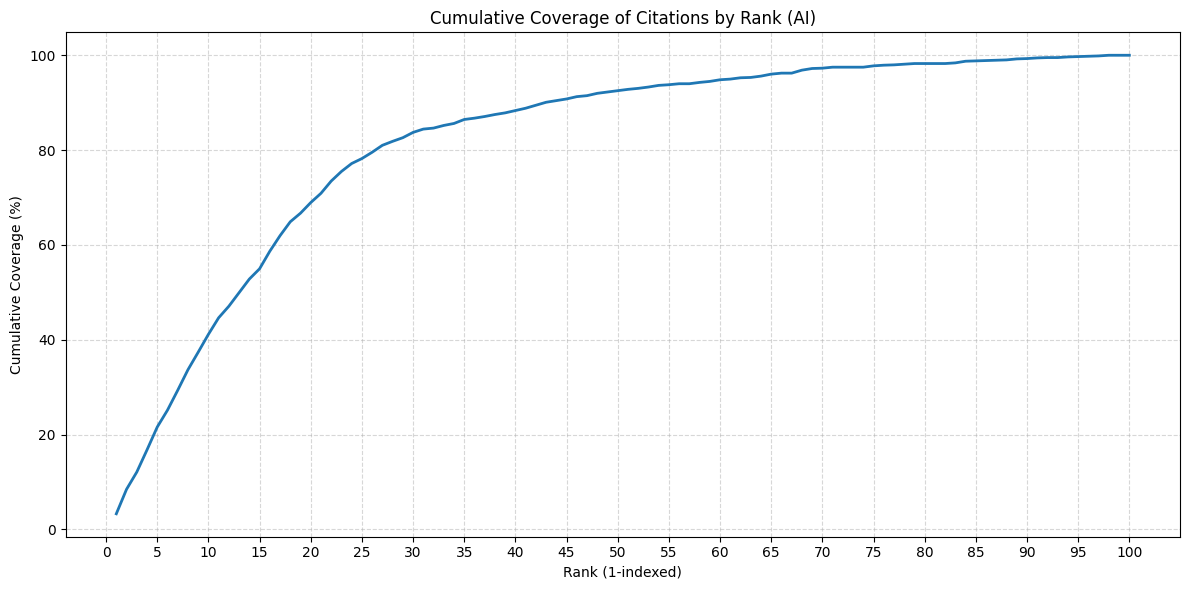

Share of citations covered by top-k ranks:
  Top-1 :   3.3%
  Top-3 :  12.1%
  Top-5 :  21.6%
  Top-10:  41.1%
  Top-20:  68.9%
  Top-30:  83.7%
  Top-40:  88.3%
  Top-50:  92.5%


In [64]:
ai_urls = set(classified_urls_df['url'][classified_urls_df['ai_class'] == 'AI'])

plot_cited_positions(responses_df, url_set=ai_urls, label='AI')
plot_cited_positions_cumulative(responses_df, url_set=ai_urls, label='AI')
print_topk_percentages(responses_df, url_set=ai_urls)

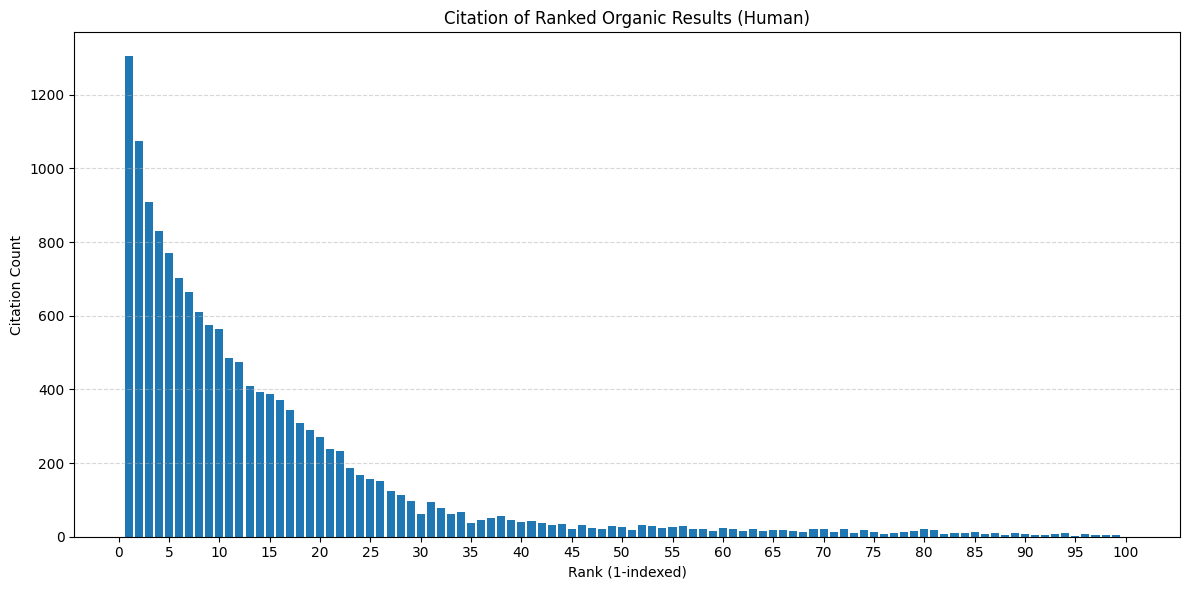

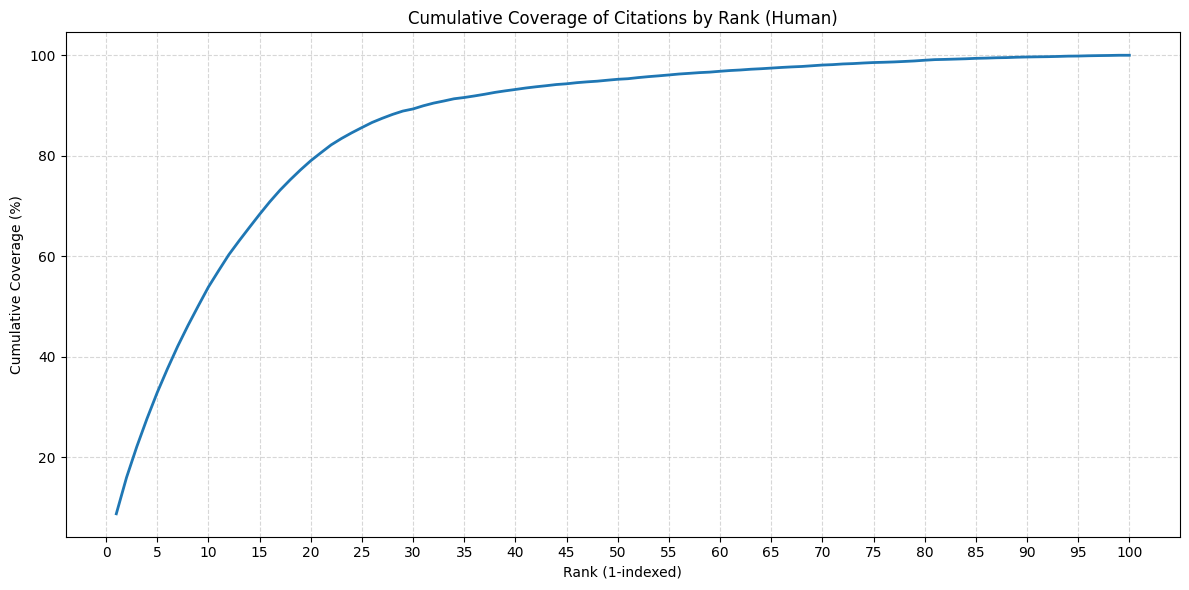

Share of citations covered by top-k ranks:
  Top-1 :   8.8%
  Top-3 :  22.1%
  Top-5 :  32.9%
  Top-10:  53.9%
  Top-20:  79.0%
  Top-30:  89.3%
  Top-40:  93.2%
  Top-50:  95.2%


In [65]:
human_urls = set(classified_urls_df['url'][classified_urls_df['ai_class'] == 'Human'])

plot_cited_positions(responses_df, url_set=human_urls, label='Human')
plot_cited_positions_cumulative(responses_df, url_set=human_urls, label='Human')
print_topk_percentages(responses_df, url_set=human_urls)

In [66]:
# P(cited | rank <= k)

k_list = list(range(1, 101))
probabilities = []

for k in k_list:
    cited = total = 0

    for _, row in responses_df.iterrows():
        citations = set(row["references"])
        top_k_organic = row["organic_results"][:k]

        for url in top_k_organic:
            total += 1
            if url in citations:
                cited += 1

    prob = cited / total if total else 0

    probabilities.append(prob * 100)

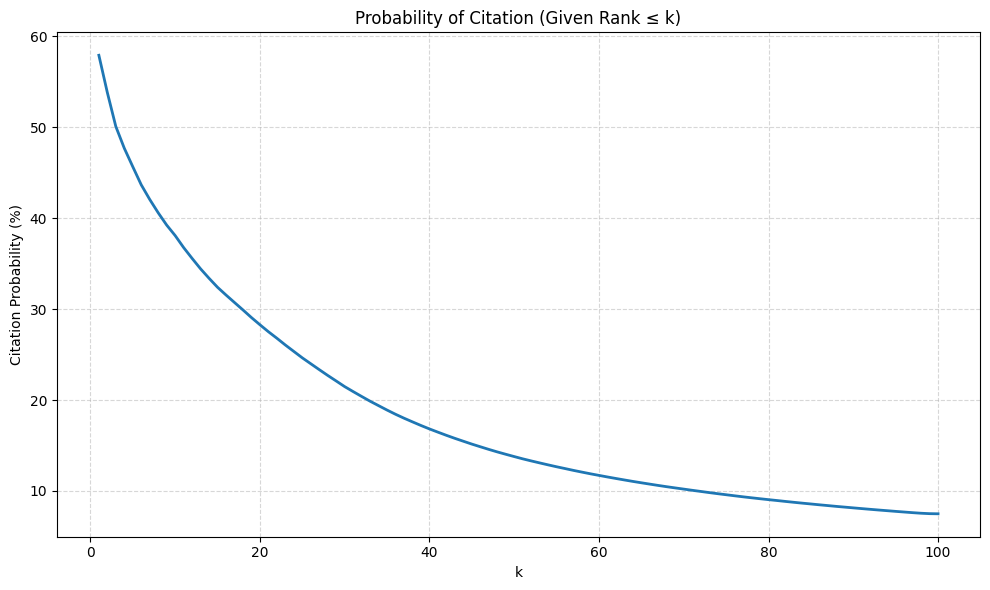

P(cited | rank ≤ k):
  k=1 : 57.91%
  k=2 : 53.81%
  k=3 : 50.08%
  k=5 : 45.66%
  k=10: 38.09%
  k=20: 28.28%
  k=30: 21.47%
  k=40: 16.82%
  k=50: 13.78%


In [67]:
plt.figure(figsize=(10, 6))
plt.plot(k_list, probabilities, '-', linewidth=2)
plt.xlabel("k")
plt.ylabel("Citation Probability (%)")
plt.title("Probability of Citation (Given Rank ≤ k)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

ks = [1, 2, 3, 5, 10, 20, 30, 40, 50]

print("P(cited | rank ≤ k):")
for k in ks:
    print(f"  k={k:<2}: {probabilities[k-1]:5.2f}%")

# Blog post 3 graphics

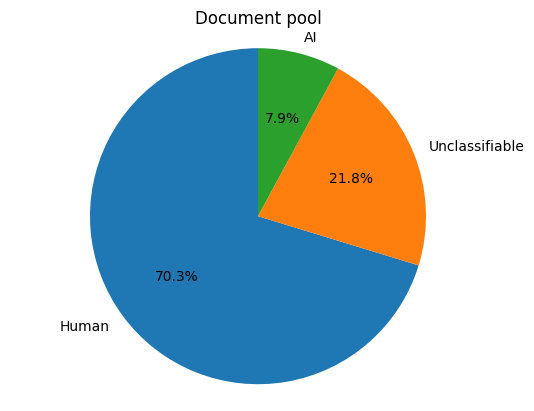

In [68]:
ai_count = len(classified_urls_df[classified_urls_df['ai_class'] == 'AI'])
human_count = len(classified_urls_df[classified_urls_df['ai_class'] == 'Human'])
unclass_count = len(unclassified_urls_df)

labels = ["Human", "Unclassifiable", "AI"]
sizes = [human_count, unclass_count, ai_count]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Document pool")
plt.axis('equal')
plt.show()